# DE-COP en BookTection — black-box, gratis (Colab)

Implementación de **DE-COP** (Duarte et al., 2024) sobre el benchmark **BookTection**
para *membership inference* en LLMs, en modo **black-box** (solo necesita la respuesta del modelo).

**Idea:** se le da al modelo una multiple-choice con el pasaje original *verbatim* + 3 paráfrasis
y se le pregunta cuál es el original. Si lo identifica consistentemente → señal de que lo vio en
el entrenamiento. Se promedia sobre permutaciones de las opciones (debiasing de posición) y se
calcula el **AUC** entre books *member* (Label=1) y *non-member* (Label=0).

Dos backends (elegís en la celda de config):
- **`groq`** → API gratis, sin GPU, OpenAI-compatible. Modelos: Llama-3.x, Gemma-2, Qwen, Mixtral.
  Ideal para tener resultados YA. ⚠️ Estos modelos tienen cutoff 2023+, así que los non-members
  de BookTection (libros 2023) están parcialmente contaminados → el AUC es un piso, no un número limpio.
- **`hf`** → corre el modelo vos en GPU (Colab T4 con tus créditos). Sirve para **Llama-2-7B**,
  que es el único temporalmente limpio para BookTection (cutoff ~sept 2022 → los libros 2023 son
  non-members reales). Llama-2 es *gated*: necesitás token de HF + aceptar la licencia.


## 1. Instalación

In [64]:
!pip install -q datasets scikit-learn pandas tqdm groq transformers accelerate

In [65]:
from google.colab import drive
drive.mount('/content/drive')

import os, glob, shutil, json
import pandas as pd
from sklearn.metrics import roc_auc_score
os.chdir('/content/drive/MyDrive/a udesa/7. septimo semestre/nlp/TP NLP 2026/notebooks')
OUTDIR = "/content/drive/MyDrive/a udesa/7. septimo semestre/nlp/TP NLP 2026/decop"
os.makedirs(OUTDIR, exist_ok=True)

BASE_DIR = "/content/drive/MyDrive/a udesa/7. septimo semestre/nlp/TP NLP 2026"

API_LOG_DIR = f"{BASE_DIR}/api_logs"
RESULTS_DIR = f"{BASE_DIR}/results"

os.makedirs(API_LOG_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

# si todavía quedan checkpoints locales, copialos al Drive como respaldo
for f in glob.glob("decop_results/*.json"):
    shutil.copy(f, OUTDIR)
print("checkpoints en Drive:", len(os.listdir(OUTDIR)))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
checkpoints en Drive: 0


## 2. Configuración

Empezá chico para validar el pipeline (≈40 min, gratis con Groq), después subís los números.


In [66]:
# ----------------- CONFIG -----------------
BACKEND = "groq"          # "groq"  o  "hf"

# Modelo segun backend:
#   groq -> "llama-3.1-8b-instant" (14.4k req/dia, el mas generoso),
#           "llama-3.3-70b-versatile", "gemma2-9b-it", "qwen-2.5-32b", "mixtral-8x7b-32768"
#   hf   -> "meta-llama/Llama-2-7b-chat-hf" (gated), "mistralai/Mistral-7B-Instruct-v0.3", etc.
MODEL = "llama-3.3-70b-versatile" #"llama-3.1-8b-instant"

LENGTH = "medium"         # "small" | "medium" | "large"  (medium ~128 tokens, como en el paper)

# Sub-muestreo para un primer run rapido. Subilos despues (None = todo).
N_BOOKS_PER_CLASS   = 10  # 10 members + 10 non-members
N_PASSAGES_PER_BOOK = 10  # el dataset trae ~30 por book
N_PERMUTATIONS      = 6   # 24 = todas (paper). 6 alcanza para un primer AUC

# Rate limiting (Groq free: ~30 req/min). Subi el sleep si te tira 429.
SLEEP_BETWEEN_CALLS = 2.1  # segundos. Para 'hf' poné 0.

SEED = 2319
# ------------------------------------------

# Claves (en Colab: icono de llave 🔑 a la izquierda -> "Secrets")
import os
try:
    from google.colab import userdata
    GROQ_API_KEY = userdata.get("GROQ_API_KEY8")  if BACKEND == "groq" else None
    HF_TOKEN     = userdata.get("HF_TOKEN")       if BACKEND == "hf"   else None
except Exception:
    GROQ_API_KEY = os.environ.get("GROQ_API_KEY8")
    HF_TOKEN     = os.environ.get("HF_TOKEN")
print("Backend:", BACKEND, "| Modelo:", MODEL)

Backend: groq | Modelo: llama-3.3-70b-versatile


## 3. Cargar BookTection desde HuggingFace

In [67]:
import pandas as pd
from datasets import load_dataset

DATASET_PATH = "/content/drive/MyDrive/a udesa/7. septimo semestre/nlp/TP NLP 2026/datasets/evaluation/booktection_medium_eval_20books_10chunks.csv"

df = pd.read_csv(DATASET_PATH)
print(df.shape)
df.head()

# Limpiar filas rotas (#NAME? aparece en algunas celdas del CSV original)
opt_cols = ["Example_A", "Example_B", "Example_C", "Example_D"]
def ok(r): return all(isinstance(r[c], str) and r[c].strip() not in ("", "#NAME?") for c in opt_cols)
df = df[df.apply(ok, axis=1)].reset_index(drop=True)

print(f"{df['book_id'].nunique()} books, {len(df)} pasajes")

print(
    "Members (1):",
    df[df["label"] == 1]["book_id"].nunique(),
    "| Non-members (0):",
    df[df["label"] == 0]["book_id"].nunique()
)
df.head(2)

(200, 10)
20 books, 200 pasajes
Members (1): 10 | Non-members (0): 10


,sample_id,book_id,label,length,answer,text,Example_A,Example_B,Example_C,Example_D
0,BT_0000,1984_-_George_Orwell,1,medium,A,Since he was arrested he had not been fed. He ...,Since he was arrested he had not been fed. He ...,He had not eaten anything since being arrested...,"Since his arrest, he had been given nothing to...",He had been given no food since being arrested...
1,BT_0001,The_Alchemist_-_Paulo_Coelho,1,medium,A,"“And I know the Soul of the World, because we ...","“And I know the Soul of the World, because we ...",The essence of the universe has confided in me...,I'm privy to the psyche of the cosmos from our...,The spirit of the world has confided in me dur...


## 4. Backend del modelo

`ask_model(options) -> 'A'|'B'|'C'|'D'`. Mismo prompt que el paper original.


In [68]:
import re, time

QA_SYS = ("You are entering a multiple choice questions exam. You should directly answer "
          "each question by choosing the correct option. Be concise and straight to the point "
          "in your answer. Output only the letter corresponding to the correct answer.")

def build_prompt(options, book, author):
    q = (f'Question: Which of the following passages is verbatim from the "{book}" '
         f'book by {author}?\nOptions:\n')
    body = "".join(f"{L}. {opt}\n" for L, opt in zip("ABCD", options))
    return q + body + "Answer:"

def parse_letter(text):
    m = re.search(r"[ABCD]", (text or "").upper())
    return m.group(0) if m else "A"   # fallback

# ---------- Groq ----------
if BACKEND == "groq":
    from groq import Groq
    _client = Groq(api_key=GROQ_API_KEY)
    def ask_model(options, book, author):
        prompt = build_prompt(options, book, author)
        r = _client.chat.completions.create(
            model=MODEL,
            messages=[{"role": "system", "content": QA_SYS},
                      {"role": "user",   "content": prompt}],
            max_tokens=2, temperature=0, seed=SEED)
        return parse_letter(r.choices[0].message.content)

# ---------- HuggingFace local (GPU) ----------
elif BACKEND == "hf":
    import torch
    from transformers import AutoModelForCausalLM, AutoTokenizer
    _tok = AutoTokenizer.from_pretrained(MODEL, token=HF_TOKEN)
    _model = AutoModelForCausalLM.from_pretrained(
        MODEL, token=HF_TOKEN, torch_dtype=torch.float16, device_map="auto")
    def ask_model(options, book, author):
        prompt = build_prompt(options, book, author)
        msgs = [{"role": "system", "content": QA_SYS}, {"role": "user", "content": prompt}]
        try:
            ids = _tok.apply_chat_template(msgs, add_generation_prompt=True, return_tensors="pt")
        except Exception:
            ids = _tok(QA_SYS + "\n" + prompt, return_tensors="pt").input_ids
        ids = ids.to(_model.device)
        out = _model.generate(ids, max_new_tokens=2, do_sample=False,
                              pad_token_id=_tok.eos_token_id)
        return parse_letter(_tok.decode(out[0, ids.shape[1]:], skip_special_tokens=True))
else:
    raise ValueError("BACKEND debe ser 'groq' o 'hf'")

# sanity check
print(ask_model(["the cat sat", "a feline rested", "the dog ran", "birds flew"],
                "Test Book", "Test Author"))

A


## 5. Permutaciones + scoring (lógica DE-COP)

In [69]:
import itertools, random
LETTERS = ["A", "B", "C", "D"]

def make_permutations(options, n_perms, rng):
    """options[0] = original verbatim; [1..3] = parafrasis.
       Devuelve [(opciones_barajadas, letra_correcta), ...]."""
    all_perms = list(itertools.permutations(range(4)))   # 24
    rng.shuffle(all_perms)
    chosen = all_perms if (n_perms is None or n_perms >= 24) else all_perms[:n_perms]
    return [([options[i] for i in p], LETTERS[p.index(0)]) for p in chosen]

## 6. Correr DE-COP

Guarda checkpoint por book en `decop_results/` → si se corta Colab, volvés a correr y sigue.


In [70]:
# ====== CELDA 6: DE-COP con cache por consulta + resultados por sample ======
import os, json, re, time, random, hashlib
import pandas as pd
from tqdm.auto import tqdm

class DailyCapError(Exception):
    pass

def safe_ask(options, book, author, max_retries=6):
    for attempt in range(max_retries):
        try:
            return ask_model(options, book, author)
        except Exception as e:
            msg = str(e)

            if "429" not in msg and "rate_limit" not in msg.lower():
                raise

            if "per day" in msg.lower() or "TPD" in msg or "RPD" in msg:
                raise DailyCapError(msg)

            m2 = re.search(r"try again in (\d+)m([\d.]+)s", msg)
            m1 = re.search(r"try again in ([\d.]+)s", msg)

            wait = (
                int(m2.group(1)) * 60 + float(m2.group(2))
                if m2 else
                float(m1.group(1)) if m1 else 20.0
            )

            time.sleep(wait + 1)

    raise RuntimeError("max_retries agotado en 429 transitorio")

def split_name(b):
    p = b.split("_-_")
    return (
        p[0].replace("_", " "),
        p[1].replace("_", " ") if len(p) > 1 else ""
    )

def save_json(path, data):
    with open(path, "w", encoding="utf-8") as f:
        json.dump(data, f, indent=2, ensure_ascii=False)

def load_json(path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

def make_query_id(method, model, sample_id, perm_idx):
    raw = f"{method}|{model}|{sample_id}|{perm_idx}|{N_PERMUTATIONS}|{SEED}"
    return hashlib.md5(raw.encode("utf-8")).hexdigest()

METHOD = "decop"

BASE_DIR = "/content/drive/MyDrive/a udesa/7. septimo semestre/nlp/TP NLP 2026"

API_LOG_DIR = os.path.join(
    BASE_DIR,
    "api_logs",
    METHOD,
    MODEL.replace("/", "_")
)

RESULTS_DIR = os.path.join(
    BASE_DIR,
    "results",
    METHOD,
    MODEL.replace("/", "_")
)

os.makedirs(API_LOG_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

random.seed(SEED)
rng = random.Random(SEED)

query_records = []
sample_records = []
stopped = False

for _, row in tqdm(df.iterrows(), total=len(df), desc="DE-COP samples"):

    sample_id = row["sample_id"]
    book_id = row["book_id"]
    label = int(row["label"])

    title, author = split_name(book_id)

    opts = [
        row["Example_A"],
        row["Example_B"],
        row["Example_C"],
        row["Example_D"]
    ]

    correct = 0
    total = 0

    try:
        for perm_idx, (shuffled, gold) in enumerate(
            make_permutations(opts, N_PERMUTATIONS, rng)
        ):

            query_id = make_query_id(METHOD, MODEL, sample_id, perm_idx)
            log_path = os.path.join(API_LOG_DIR, f"{query_id}.json")

            if os.path.exists(log_path):
                record = load_json(log_path)
                pred = record["predicted_letter"]
                hit = int(record["is_correct"])

            else:
                prompt = build_prompt(shuffled, title, author)

                pred = safe_ask(shuffled, title, author)
                hit = int(pred == gold)

                record = {
                    "query_id": query_id,
                    "method": METHOD,
                    "model": MODEL,
                    "backend": BACKEND,
                    "sample_id": sample_id,
                    "book_id": book_id,
                    "label": label,
                    "title": title,
                    "author": author,
                    "length": LENGTH,
                    "permutation_index": perm_idx,
                    "n_permutations": N_PERMUTATIONS,
                    "prompt": prompt,
                    "options": {
                        "A": shuffled[0],
                        "B": shuffled[1],
                        "C": shuffled[2],
                        "D": shuffled[3],
                    },
                    "gold_letter": gold,
                    "predicted_letter": pred,
                    "is_correct": hit,
                    "timestamp": time.strftime("%Y-%m-%d %H:%M:%S")
                }

                save_json(log_path, record)

                if SLEEP_BETWEEN_CALLS:
                    time.sleep(SLEEP_BETWEEN_CALLS)

            query_records.append(record)

            correct += hit
            total += 1

        membership_probability = correct / total

        sample_records.append({
            "sample_id": sample_id,
            "book_id": book_id,
            "label": label,
            "method": METHOD,
            "model": MODEL,
            "backend": BACKEND,
            "membership_probability": membership_probability,
            "n_queries": total,
            "n_correct": correct,
            "absolute_error": abs(label - membership_probability)
        })

    except DailyCapError:
        stopped = True
        print("\n⚠️ Cap diario de Groq alcanzado.")
        print("Reanudá luego re-corriendo esta celda: las consultas ya guardadas no se repiten.")
        break

query_df = pd.DataFrame(query_records)
sample_df = pd.DataFrame(sample_records)

query_csv = os.path.join(RESULTS_DIR, "decop_query_level_results.csv")
sample_csv = os.path.join(RESULTS_DIR, "decop_sample_level_results.csv")

query_df.to_csv(query_csv, index=False)
sample_df.to_csv(sample_csv, index=False)

print("CORTADO por cap diario." if stopped else "COMPLETO.")
print("Consultas guardadas:", len(query_df))
print("Samples completos:", len(sample_df))

print("\nQuery-level guardado en:")
print(query_csv)

print("\nSample-level guardado en:")
print(sample_csv)

display(sample_df.head())

DE-COP samples:   0%|          | 0/200 [00:00<?, ?it/s]

COMPLETO.
Consultas guardadas: 1200
Samples completos: 200

Query-level guardado en:
/content/drive/MyDrive/a udesa/7. septimo semestre/nlp/TP NLP 2026/results/decop/llama-3.3-70b-versatile/decop_query_level_results.csv

Sample-level guardado en:
/content/drive/MyDrive/a udesa/7. septimo semestre/nlp/TP NLP 2026/results/decop/llama-3.3-70b-versatile/decop_sample_level_results.csv


,sample_id,book_id,label,method,model,backend,membership_probability,n_queries,n_correct,absolute_error
0,BT_0000,1984_-_George_Orwell,1,decop,llama-3.3-70b-versatile,groq,1.0,6,6,0.0
1,BT_0001,The_Alchemist_-_Paulo_Coelho,1,decop,llama-3.3-70b-versatile,groq,1.0,6,6,0.0
2,BT_0002,Oliver_Twist_-_Charles_Dickens,1,decop,llama-3.3-70b-versatile,groq,1.0,6,6,0.0
3,BT_0003,Unfortunately_Yours_-_Tessa_Bailey,0,decop,llama-3.3-70b-versatile,groq,0.0,6,0,0.0
4,BT_0004,The_Foxglove_King_-_Hannah_Whitten,0,decop,llama-3.3-70b-versatile,groq,1.0,6,6,1.0


In [71]:
if len(sample_df) > 0:
    print("Mean Absolute Error:", sample_df["absolute_error"].mean())

    print("\nError por clase:")
    print(sample_df.groupby("label")["absolute_error"].mean())

    if sample_df["label"].nunique() == 2:
        from sklearn.metrics import roc_auc_score

        auc = roc_auc_score(
            sample_df["label"],
            sample_df["membership_probability"]
        )

        print("\nAUC:", auc)
    else:
        print("\nTodavía no se puede calcular AUC: falta una de las clases.")

Mean Absolute Error: 0.285

Error por clase:
label
0    0.535
1    0.035
Name: absolute_error, dtype: float64

AUC: 0.86815


## 7. Resultados: AUC + curva ROC

Modelo: llama-3.3-70b-versatile
Método: DE-COP
Samples completos: 200

Mean Absolute Error:
0.285

Error por clase:
label
0    0.535
1    0.035
Name: absolute_error, dtype: float64

AUC: 0.86815


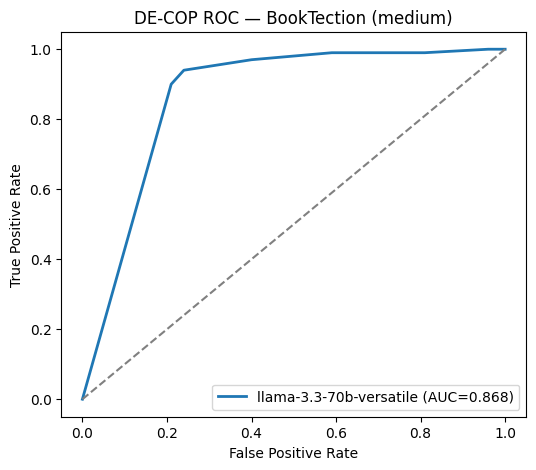


Métricas guardadas en:
/content/drive/MyDrive/a udesa/7. septimo semestre/nlp/TP NLP 2026/results/decop/llama-3.3-70b-versatile/decop_metrics_summary.csv


In [72]:
import os
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve

print("Modelo:", MODEL)
print("Método: DE-COP")
print("Samples completos:", len(sample_df))

print("\nMean Absolute Error:")
print(sample_df["absolute_error"].mean())

print("\nError por clase:")
print(sample_df.groupby("label")["absolute_error"].mean())

if sample_df["label"].nunique() == 2:
    y = sample_df["label"].values
    s = sample_df["membership_probability"].values

    auc = roc_auc_score(y, s)
    print("\nAUC:", auc)

    fpr, tpr, _ = roc_curve(y, s)

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, lw=2, label=f"{MODEL} (AUC={auc:.3f})")
    plt.plot([0, 1], [0, 1], "--", color="grey")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"DE-COP ROC — BookTection ({LENGTH})")
    plt.legend(loc="lower right")
    plt.show()
else:
    print("\nTodavía no se puede calcular AUC: falta una de las clases.")

metrics_path = os.path.join(RESULTS_DIR, "decop_metrics_summary.csv")

metrics_summary = pd.DataFrame([{
    "method": "decop",
    "model": MODEL,
    "backend": BACKEND,
    "length": LENGTH,
    "n_samples": len(sample_df),
    "mean_absolute_error": sample_df["absolute_error"].mean(),
    "mean_error_members": sample_df[sample_df["label"] == 1]["absolute_error"].mean(),
    "mean_error_non_members": sample_df[sample_df["label"] == 0]["absolute_error"].mean(),
    "auc": auc if sample_df["label"].nunique() == 2 else None
}])

metrics_summary.to_csv(metrics_path, index=False)

print("\nMétricas guardadas en:")
print(metrics_path)

## Para escalar a "todos los modelos que BookTection permite"

1. Validá con la config chica de arriba (Groq, llama-3.1-8b-instant).
2. Subí `N_BOOKS_PER_CLASS=None`, `N_PASSAGES_PER_BOOK=None`, `N_PERMUTATIONS=24` para el run completo
   (ojo con el cap diario de Groq: ~14.4k req/día en el 8B; el resto 1k/día).
3. Cambiá `MODEL` y volvé a correr — cada modelo guarda su propio CSV.
   - **Groq (sin GPU):** `llama-3.3-70b-versatile`, `gemma2-9b-it`, `qwen-2.5-32b`, `mixtral-8x7b-32768`.
   - **HF en GPU (`BACKEND="hf"`, tus créditos):** `meta-llama/Llama-2-7b-chat-hf` (el limpio para
     BookTection), `mistralai/Mistral-7B-Instruct-v0.3`, `Qwen/Qwen2.5-7B-Instruct`, `google/gemma-2-9b-it`.
4. Para comparar modelos: juntá los CSV y graficá los AUC. Recordá el caveat temporal: para modelos
   con cutoff 2023+ el AUC de BookTection mezcla memorización real con contaminación de los non-members.
